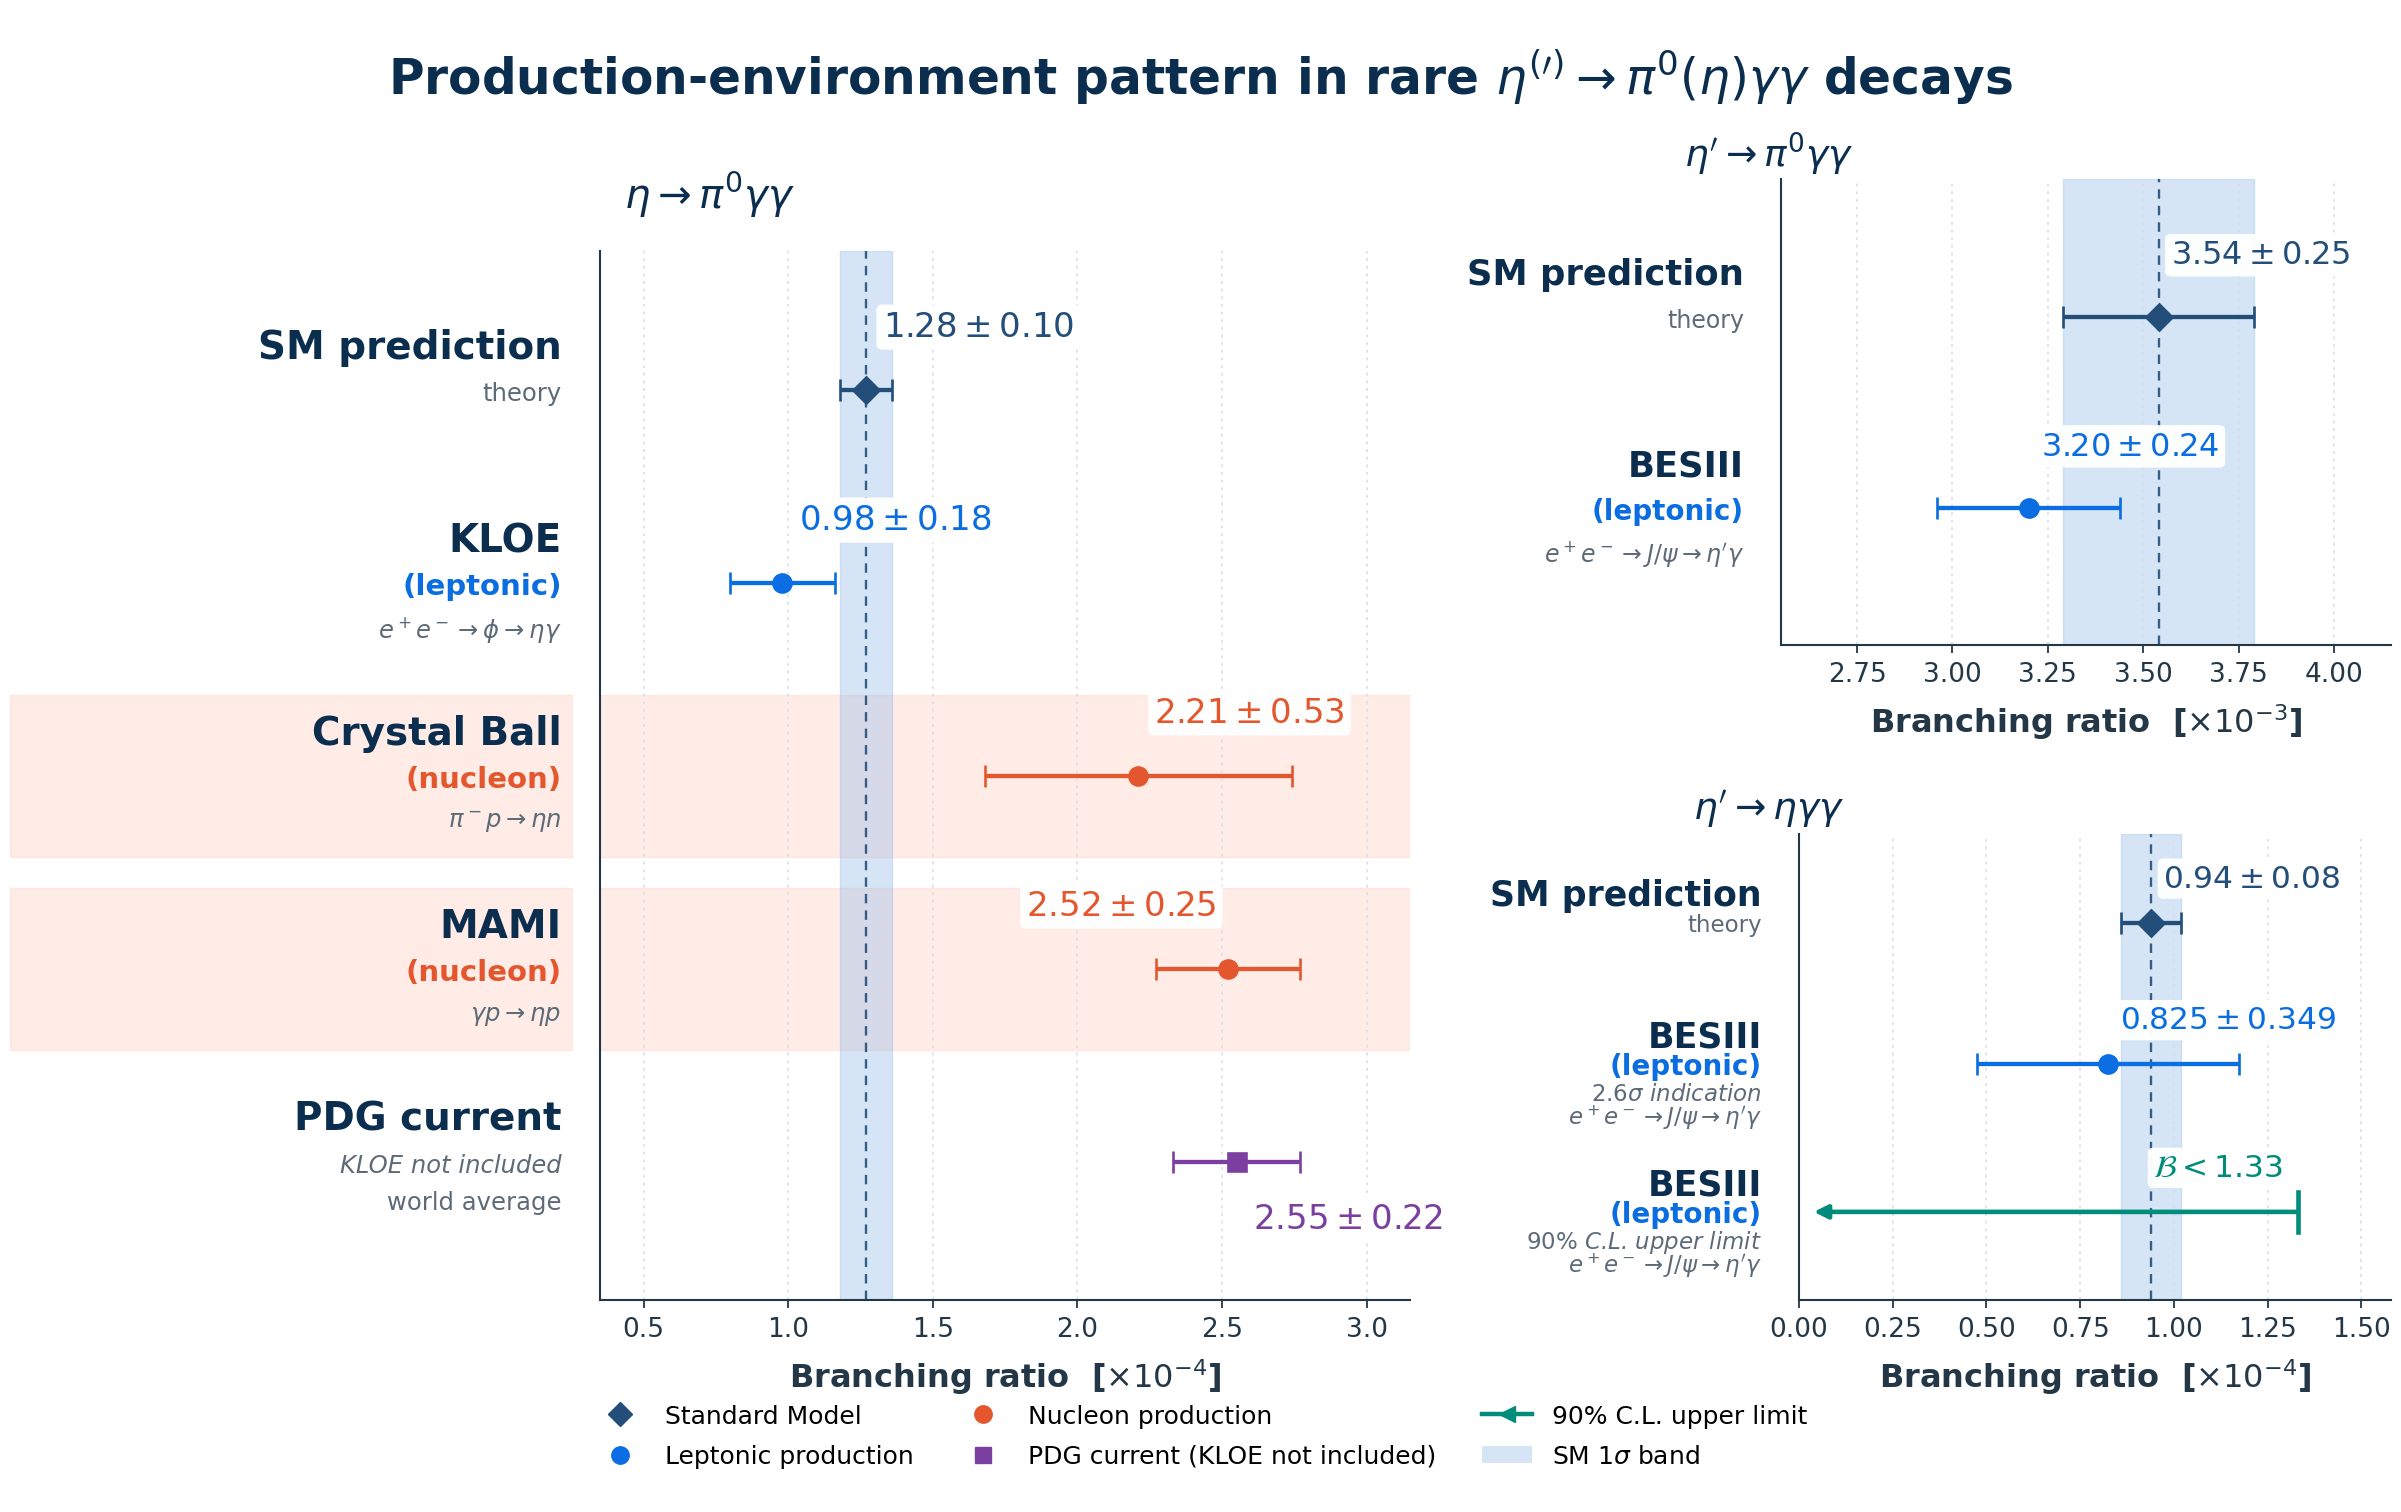

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ============================================================
# Production-environment pattern in rare eta decays
# Maximum readability version
# ============================================================

plt.close("all")

# -------------------- Colors --------------------

C_TITLE = "#0B2E4F"
C_TEXT = "#243746"
C_MUTED = "#5D6B78"

C_SM = "#244E7A"
C_LEPTON = "#0A6DE1"
C_NUCLEON = "#E4572E"
C_PDG = "#7B3FA0"
C_LIMIT = "#008C7A"

C_SM_BAND = "#8FB8E8"
C_NUCLEON_BG = "#FFB39E"
C_GRID = "#D5DEE8"

# -------------------- Typography --------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.sans-serif": [
        "DejaVu Sans",
        "Arial",
        "Liberation Sans",
    ],
    "mathtext.fontset": "dejavusans",

    "font.size": 20,
    "axes.labelsize": 23,
    "axes.labelweight": "bold",
    "xtick.labelsize": 19,

    "axes.linewidth": 1.5,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# Panel builder
# ============================================================

def make_panel(
    fig,
    subspec,
    rows,
    title,
    xlim,
    xlabel,
    sm_center,
    sm_error,
    label_width=0.44,
    title_fs=28,
    label_fs=27,
    env_fs=21,
    sub_fs=17.5,
    value_fs=24,
    highlight_rows=(),
):
    """
    Large-font, no-overlap panel.
    """

    panel_grid = subspec.subgridspec(
        2,
        1,
        height_ratios=[0.11, 0.89],
        hspace=0.0,
    )

    ax_title = fig.add_subplot(panel_grid[0])
    ax_title.axis("off")

    ax_title.text(
        0.5,
        0.44,
        title,
        ha="center",
        va="center",
        fontsize=title_fs,
        fontweight="bold",
        color=C_TITLE,
    )

    body_grid = panel_grid[1].subgridspec(
        1,
        2,
        width_ratios=[label_width, 1.0 - label_width],
        wspace=0.04,
    )

    ax_labels = fig.add_subplot(body_grid[0])
    ax_plot = fig.add_subplot(body_grid[1])

    y_values = np.asarray(
        [row["y"] for row in rows],
        dtype=float,
    )

    ymin = np.min(y_values) - 0.72
    ymax = np.max(y_values) + 0.72

    ax_labels.set_xlim(0.0, 1.0)
    ax_labels.set_ylim(ymin, ymax)
    ax_labels.axis("off")

    ax_plot.set_xlim(*xlim)
    ax_plot.set_ylim(ymin, ymax)

    xspan = xlim[1] - xlim[0]

    # -------------------- Highlight nucleon rows --------------------

    for row_index in highlight_rows:
        y = rows[row_index]["y"]

        for ax in (ax_labels, ax_plot):
            ax.axhspan(
                y - 0.42,
                y + 0.42,
                color=C_NUCLEON_BG,
                alpha=0.24,
                zorder=-2,
            )

    # -------------------- SM band --------------------

    ax_plot.axvspan(
        sm_center - sm_error,
        sm_center + sm_error,
        color=C_SM_BAND,
        alpha=0.36,
        zorder=-1,
    )

    ax_plot.axvline(
        sm_center,
        color=C_SM,
        linewidth=1.7,
        linestyle=(0, (4, 3)),
        alpha=0.9,
        zorder=0,
    )

    # -------------------- Rows --------------------

    for row in rows:
        y = row["y"]
        color = row["color"]

        ax_labels.text(
            0.98,
            y + 0.22,
            row["name"],
            ha="right",
            va="center",
            fontsize=label_fs,
            fontweight="bold",
            color=C_TITLE,
        )

        current_y = y - 0.02

        if row.get("environment"):
            environment_color = (
                C_NUCLEON
                if row["environment"] == "nucleon"
                else C_LEPTON
            )

            ax_labels.text(
                0.98,
                current_y,
                f'({row["environment"]})',
                ha="right",
                va="center",
                fontsize=env_fs,
                fontweight="bold",
                color=environment_color,
            )

            current_y -= 0.22

        if row.get("note"):
            ax_labels.text(
                0.98,
                current_y,
                row["note"],
                ha="right",
                va="center",
                fontsize=sub_fs,
                color=C_MUTED,
                style="italic",
            )

            current_y -= 0.19

        if row.get("channel"):
            ax_labels.text(
                0.98,
                current_y,
                row["channel"],
                ha="right",
                va="center",
                fontsize=sub_fs,
                color=C_MUTED,
                linespacing=1.08,
            )

        if row.get("kind", "point") == "upper":
            upper_limit = row["x"]
            arrow_end = xlim[0] + 0.025 * xspan

            ax_plot.annotate(
                "",
                xy=(arrow_end, y),
                xytext=(upper_limit, y),
                arrowprops={
                    "arrowstyle": "-|>",
                    "linewidth": 3.3,
                    "color": color,
                    "shrinkA": 0,
                    "shrinkB": 0,
                },
                zorder=5,
            )

            ax_plot.plot(
                [upper_limit, upper_limit],
                [y - 0.16, y + 0.16],
                color=color,
                linewidth=3.3,
                zorder=5,
            )

        else:
            ax_plot.errorbar(
                row["x"],
                y,
                xerr=row["err"],
                fmt=row.get("marker", "o"),
                markersize=row.get("ms", 13.0),
                markerfacecolor=color,
                markeredgecolor=color,
                markeredgewidth=1.9,
                ecolor=color,
                elinewidth=3.1,
                capsize=8.0,
                capthick=2.8,
                zorder=5,
            )

        value_x = row["x"] + row.get("dx", 0.020) * xspan
        value_y = y + row.get("dy", 0.24)

        ax_plot.text(
            value_x,
            value_y,
            row["value_text"],
            ha=row.get("ha", "left"),
            va="bottom",
            fontsize=value_fs,
            fontweight="bold",
            color=color,
            bbox={
                "boxstyle": "round,pad=0.18",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.97,
            },
            zorder=6,
        )

    # -------------------- Axes styling --------------------

    ax_plot.set_yticks([])

    ax_plot.set_xlabel(
        xlabel,
        color=C_TEXT,
        labelpad=10,
        fontweight="bold",
    )

    ax_plot.grid(
        axis="x",
        color=C_GRID,
        linestyle=(0, (2, 3)),
        linewidth=1.1,
    )

    ax_plot.set_axisbelow(True)

    ax_plot.spines["top"].set_visible(False)
    ax_plot.spines["right"].set_visible(False)
    ax_plot.spines["left"].set_color(C_TEXT)
    ax_plot.spines["bottom"].set_color(C_TEXT)

    ax_plot.tick_params(
        axis="x",
        colors=C_TEXT,
        length=5.5,
        width=1.3,
        pad=6,
    )

    return ax_plot


# ============================================================
# Data
# ============================================================

eta_pi0_rows = [
    {
        "y": 5.0,
        "name": "SM prediction",
        "channel": "theory",
        "x": 1.27,
        "err": 0.09,
        "color": C_SM,
        "marker": "D",
        "value_text": r"$1.28 \pm 0.10$",
    },
    {
        "y": 4.0,
        "name": "KLOE",
        "environment": "leptonic",
        "channel": r"$e^+e^- \rightarrow \phi \rightarrow \eta\gamma$",
        "x": 0.98,
        "err": 0.18,
        "color": C_LEPTON,
        "value_text": r"$0.98 \pm 0.18$",
    },
    {
        "y": 3.0,
        "name": "Crystal Ball",
        "environment": "nucleon",
        "channel": r"$\pi^- p \rightarrow \eta n$",
        "x": 2.21,
        "err": 0.53,
        "color": C_NUCLEON,
        "value_text": r"$2.21 \pm 0.53$",
    },
    {
        "y": 2.0,
        "name": "MAMI",
        "environment": "nucleon",
        "channel": r"$\gamma p \rightarrow \eta p$",
        "x": 2.52,
        "err": 0.25,
        "color": C_NUCLEON,
        "value_text": r"$2.52 \pm 0.25$",
        "ha": "right",
        "dx": -0.014,
    },
    {
        "y": 1.0,
        "name": "PDG current",
        "note": "KLOE not included",
        "channel": "world average",
        "x": 2.55,
        "err": 0.22,
        "color": C_PDG,
        "marker": "s",
        "value_text": r"$2.55 \pm 0.22$",
        "dy": -0.38,
    },
]

eta_prime_pi0_rows = [
    {
        "y": 2.0,
        "name": "SM prediction",
        "channel": "theory",
        "x": 3.54,
        "err": 0.25,
        "color": C_SM,
        "marker": "D",
        "value_text": r"$3.54 \pm 0.25$",
    },
    {
        "y": 1.0,
        "name": "BESIII",
        "environment": "leptonic",
        "channel": r"$e^+e^- \rightarrow J/\psi \rightarrow \eta^\prime\gamma$",
        "x": 3.20,
        "err": 0.24,
        "color": C_LEPTON,
        "value_text": r"$3.20 \pm 0.24$",
    },
]

eta_prime_eta_rows = [
    {
        "y": 3.10,
        "name": "SM prediction",
        "channel": "theory",
        "x": 0.94,
        "err": 0.08,
        "color": C_SM,
        "marker": "D",
        "value_text": r"$0.94 \pm 0.08$",
    },
    {
        "y": 1.95,
        "name": "BESIII",
        "environment": "leptonic",
        "note": r"$2.6\sigma$ indication",
        "channel": r"$e^+e^- \rightarrow J/\psi \rightarrow \eta^\prime\gamma$",
        "x": 0.825,
        "err": 0.349,
        "color": C_LEPTON,
        "value_text": r"$0.825 \pm 0.349$",
    },
    {
        "y": 0.75,
        "name": "BESIII",
        "environment": "leptonic",
        "note": r"$90\%$ C.L. upper limit",
        "channel": r"$e^+e^- \rightarrow J/\psi \rightarrow \eta^\prime\gamma$",
        "x": 1.33,
        "color": C_LIMIT,
        "kind": "upper",
        "value_text": r"$\mathcal{B} < 1.33$",
        "ha": "right",
        "dx": -0.024,
    },
]


# ============================================================
# Figure
# ============================================================

fig = plt.figure(
    figsize=(24.5, 15.2),
    facecolor="white",
)

outer_grid = fig.add_gridspec(
    4,
    1,
    height_ratios=[0.075, 0.79, 0.03, 0.105],
    hspace=0.0,
)

# -------------------- Main title --------------------

ax_header = fig.add_subplot(outer_grid[0])
ax_header.axis("off")

ax_header.text(
    0.5,
    0.40,
    r"Production-environment pattern in rare "
    r"$\eta^{(\prime)}\rightarrow\pi^0(\eta)\gamma\gamma$ decays",
    ha="center",
    va="center",
    fontsize=35,
    fontweight="bold",
    color=C_TITLE,
)

# ============================================================
# Main panel layout
#
# The right block is now pulled substantially left.
# Previous value: wspace = 0.00
# New value:      wspace = -0.20
# ============================================================

content_grid = outer_grid[1].subgridspec(
    1,
    2,
    width_ratios=[1.18, 1.05],
    wspace=-0.20,
)

right_grid = content_grid[1].subgridspec(
    2,
    1,
    hspace=0.25,
)

make_panel(
    fig=fig,
    subspec=content_grid[0],
    rows=eta_pi0_rows,
    title=r"$\eta\rightarrow\pi^0\gamma\gamma$",
    xlim=(0.35, 3.15),
    xlabel=r"Branching ratio  [$\times 10^{-4}$]",
    sm_center=1.27,
    sm_error=0.09,
    label_width=0.41,
    title_fs=29,
    label_fs=28,
    env_fs=21,
    sub_fs=17.5,
    value_fs=24.5,
    highlight_rows=(2, 3),
)

make_panel(
    fig=fig,
    subspec=right_grid[0],
    rows=eta_prime_pi0_rows,
    title=r"$\eta^\prime\rightarrow\pi^0\gamma\gamma$",
    xlim=(2.55, 4.15),
    xlabel=r"Branching ratio  [$\times 10^{-3}$]",
    sm_center=3.54,
    sm_error=0.25,
    label_width=0.50,
    title_fs=27,
    label_fs=25.5,
    env_fs=20,
    sub_fs=17,
    value_fs=23,
)

make_panel(
    fig=fig,
    subspec=right_grid[1],
    rows=eta_prime_eta_rows,
    title=r"$\eta^\prime\rightarrow\eta\gamma\gamma$",
    xlim=(0.00, 1.58),
    xlabel=r"Branching ratio  [$\times 10^{-4}$]",
    sm_center=0.94,
    sm_error=0.08,
    label_width=0.515,
    title_fs=27,
    label_fs=25,
    env_fs=20,
    sub_fs=16.5,
    value_fs=22.5,
)

# -------------------- Spacer --------------------

ax_spacer = fig.add_subplot(outer_grid[2])
ax_spacer.axis("off")

# -------------------- Legend --------------------

ax_legend = fig.add_subplot(outer_grid[3])
ax_legend.axis("off")

legend_handles = [
    Line2D(
        [0], [0],
        marker="D",
        color=C_SM,
        markerfacecolor=C_SM,
        markersize=12,
        linewidth=0,
        label="Standard Model",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color=C_LEPTON,
        markerfacecolor=C_LEPTON,
        markersize=12.5,
        linewidth=0,
        label="Leptonic production",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color=C_NUCLEON,
        markerfacecolor=C_NUCLEON,
        markersize=12.5,
        linewidth=0,
        label="Nucleon production",
    ),
    Line2D(
        [0], [0],
        marker="s",
        color=C_PDG,
        markerfacecolor=C_PDG,
        markersize=12,
        linewidth=0,
        label="PDG current (KLOE not included)",
    ),
    Line2D(
        [0], [0],
        color=C_LIMIT,
        linewidth=3.2,
        marker="<",
        markersize=11.5,
        label="90% C.L. upper limit",
    ),
    Patch(
        facecolor=C_SM_BAND,
        alpha=0.36,
        edgecolor="none",
        label=r"SM $1\sigma$ band",
    ),
]

ax_legend.legend(
    handles=legend_handles,
    loc="center",
    bbox_to_anchor=(0.5, 0.42),
    ncol=3,
    frameon=False,
    fontsize=18,
    handletextpad=0.80,
    columnspacing=1.80,
    labelspacing=0.65,
    borderaxespad=0.0,
)

# -------------------- Final canvas margins --------------------

fig.subplots_adjust(
    left=0.022,
    right=0.994,
    top=0.994,
    bottom=0.012,
)

# -------------------- Export --------------------

fig.savefig(
    "eta_etaPrime_environment_summary_tightly_packed.pdf",
    bbox_inches="tight",
    pad_inches=0.08,
)

fig.savefig(
    "eta_etaPrime_environment_summary_tightly_packed.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.08,
)

plt.show()